<a href="https://colab.research.google.com/github/gph05010/Daily-Study-Log-DeepLearning/blob/main/DeepLearning/ex03_%EC%86%90%EA%B8%80%EC%94%A8_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 목표
- 0~9까지 숫자를 쓴 이미지 데이터를 가져와서 어떤 숫자를 쓴 건지 예측(다중 분류)

### 실습 시 중요한 부분
1. 다중 분류에서는 출력층의 활성화함수가 어떻게 바뀌는지
2. 다중 분류에서는 compile 시 loss 값이 어떻게 설정되는지
3. 이미지 데이터를 모델에 넘기는 과정
4. 오차역전파 개념 정리

In [ ]:
# keras에서 제공하는 데이터셋 사용
from tensorflow.keras.datasets import mnist

In [ ]:
# 훈련용, 테스트용 데이터를 나눠서 제공
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
mnist.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
# 학습용 데이터 6만장, 테스트용 데이터 1만장
# 1개의 문제데이터 -> 28*28 픽셀을 가지는 이미지
# 픽셀 : 사진의 정보를 가지는 가장 작은 단위

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 정답 데이터 확인
np.unique(y_train)
# 0~9 손글씨 데이터
# 0~9까지의 숫자 중 하나를 예측하는 모델링 진행
# 정답 클래스 10개 -> 다중 분류

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

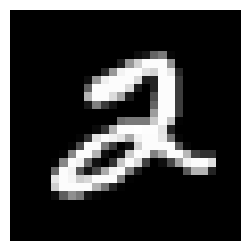

In [ ]:
# 이미지 데이터 출력해서 확인
plt.figure(figsize=(3,3))
plt.imshow(X_train[5], cmap="gray")
plt.axis(False)
plt.show()

In [ ]:
# 실제 정답 확인해보기
y_train[5]

np.uint8(2)

### MLP 모델링
- 입력층의 구조(2차원 이미지 학습)
- 출력층 구조, loss function(다중 분류)

In [ ]:
# 필요 라이브러리 불러오기
from tensorflow.keras.models import Sequential # 인공신경망의 뼈대
from tensorflow.keras.layers import Dense, InputLayer, Flatten # Flatten : 이미지 데이터 변환해주는 레이어
# Dense : 은닉층, 중간층
# InputLayer : 문제 데이터를 받아줄 층
# Flatten : 2차원 형태의 사진 데이터를 1차원으로 펴주는 역할

In [ ]:
# 모델 설계
# 1. 뼈대 생성
model = Sequential()

# 2. 입력층
model.add(InputLayer(shape=(28,28,1))) # 가로, 세로, 컬러(색상(채널)수, 흑백은 1개)

# 2차원 -> 1차원 변환 : Dense는 입력을 1차원으로만 받음
model.add(Flatten())

# 3. 중간층
model.add(Dense(units=16, activation="sigmoid"))
model.add(Dense(units=8, activation="sigmoid"))

# 4. 출력층
model.add(Dense(units=10, activation="softmax"))
# softmax : 다중 분류 시 출력층에서 사용하는 활성화 함수
# 각각 클래스에 속할 확률 -> 총 합이 1

In [ ]:
# 모델 학습 방법
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer = "SGD",
    metrics=["accuracy"]
)
# loss : 모델의 오차 측정 방법 -> 예측 결과값의 유형에 따라 달라짐
# 회귀 : mean_squared_error
# 이진 분류 : binary_crossentropy
# 다중 분류
# 1) categorical_crossentropy : 정답 결과가 원핫인코딩 되어 있을 때
# (강아지, 고양이, 새) : 강아지 = [1, 0, 0]
# 2) sparse_categorical_crossentropy : 정답 결과가 정수 형태의 클래스로 되어 있을 때
# (강아지, 고양이, 새) : 강아지 = 0, 고양이 = 1, 새 = 2

In [ ]:
# 학습
h = model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 20
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3526 - loss: 2.1777 - val_accuracy: 0.5322 - val_loss: 2.0401
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5759 - loss: 1.8869 - val_accuracy: 0.6224 - val_loss: 1.7248
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6531 - loss: 1.5762 - val_accuracy: 0.7177 - val_loss: 1.4260
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7310 - loss: 1.3162 - val_accuracy: 0.7677 - val_loss: 1.2087
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7811 - loss: 1.1239 - val_accuracy: 0.8117 - val_loss: 1.0177
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8013 - loss: 0.9824 - val_accuracy: 0.7951 - val_loss: 0.9396
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8106 - loss: 0.8761 - val_accuracy: 0.8198 - val_loss: 0.8249
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8173 - loss: 0.8048 - 

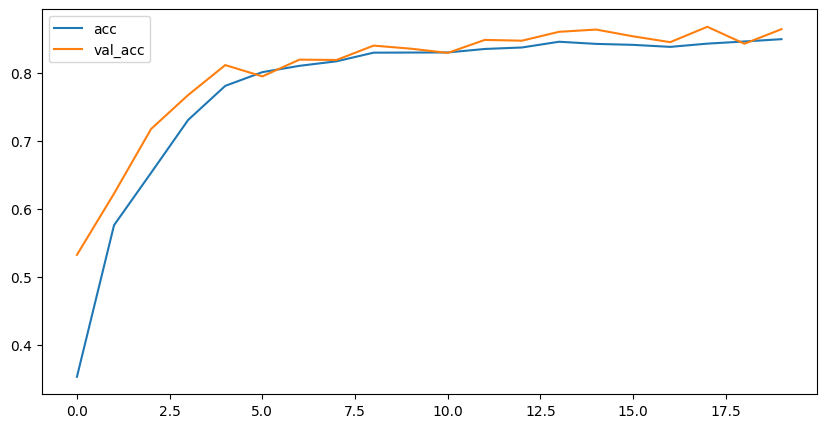

In [ ]:
# accuracy, val_accuracy
plt.figure(figsize=(10, 5))
plt.plot(h.history["accuracy"], label="acc")
plt.plot(h.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

In [ ]:
# 정답 데이터의 형태를 원핫 인코딩의 형태로 변경
from tensorflow.keras.utils import to_categorical

y_train_one_hot = to_categorical(y_train)
y_train_one_hot

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [ ]:
model.compile(
    loss="categorical_crossentropy",
    optimizer = "SGD",
    metrics=["accuracy"]
)

In [ ]:
# 학습
h = model.fit(
    X_train, y_train_one_hot,
    validation_split = 0.2,
    epochs = 20
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8521 - loss: 0.5144 - val_accuracy: 0.8658 - val_loss: 0.4811
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8557 - loss: 0.4983 - val_accuracy: 0.8655 - val_loss: 0.4915
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8556 - loss: 0.4977 - val_accuracy: 0.8502 - val_loss: 0.5105
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8589 - loss: 0.4884 - val_accuracy: 0.8710 - val_loss: 0.4512
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8440 - loss: 0.5289 - val_accuracy: 0.8701 - val_loss: 0.4667
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8628 - loss: 0.4728 - val_accuracy: 0.8773 - val_loss: 0.4443
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8691 - loss: 0.4615 - val_accuracy: 0.8791 - val_loss: 0.4388
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8636 - loss: 0.4678 - 

In [ ]:
# 모델 평가
y_test_one_hot =  to_categorical(y_test)
model.evaluate(X_test, y_test_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8780 - loss: 0.4187


[0.41872456669807434, 0.878000020980835]

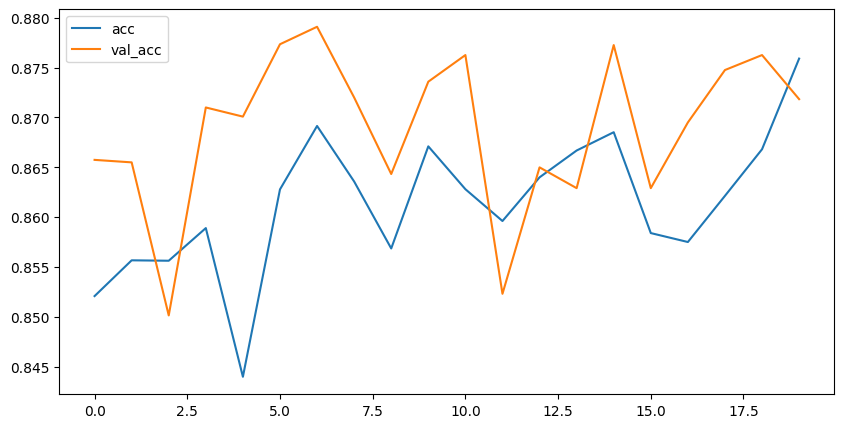

In [ ]:
# accuracy, val_accuracy
plt.figure(figsize=(10, 5))
plt.plot(h.history["accuracy"], label="acc")
plt.plot(h.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

### 최적화 함수 클래스로 불러오기
- 학습률 조정 가능

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

In [ ]:
# 1. 모멘텀 + 학습률 조정
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer = SGD(learning_rate=0.001, momentum=0.9),
    metrics=["accuracy"]
)
# 모멘텀(Momentum) : 관성, 과거에 이동했던 방향, 크기를 누적해서 다음 이동에 반영하는 원리
# 1) 학습 속도 향상
# 2) local minima(지역 최소점) 탈출 : 얕은 local minima나 작은 요철, 흔들리는 구간에 덜 붙잡히게 해 준다
# 3) 지그재그 현상 완화

h = model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 20
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8667 - loss: 0.4483 - val_accuracy: 0.8707 - val_loss: 0.4315
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8710 - loss: 0.4359 - val_accuracy: 0.8802 - val_loss: 0.4187
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8810 - loss: 0.4140 - val_accuracy: 0.8812 - val_loss: 0.4198
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8749 - loss: 0.4340 - val_accuracy: 0.8768 - val_loss: 0.4152
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8705 - loss: 0.4368 - val_accuracy: 0.8861 - val_loss: 0.4012
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8635 - loss: 0.4565 - val_accuracy: 0.8615 - val_loss: 0.4761
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8595 - loss: 0.4722 - val_accuracy: 0.8730 - val_loss: 0.4385
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8718 - loss: 0.4315 - 

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer = Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

### 내가 직접 모델 구성해보기
- model 3개 만들어서 성능 비교(학습 현황 그래프 그려서)
- 중간층의 activation -> sigmoid, relu
- compile optimizer -> SGD(학습률 변경, 모멘텀), Adam(기본, 학습률 변경), RMSProp
- 중간층 더 깊게도 쌓아보고, unit 개수도 늘려보기

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.2056 - loss: 2.2819 - val_accuracy: 0.2555 - val_loss: 2.2371
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3259 - loss: 2.1765 - val_accuracy: 0.3665 - val_loss: 2.0931
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3613 - loss: 1.9611 - val_accuracy: 0.3672 - val_loss: 1.8227
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4046 - loss: 1.7127 - val_accuracy: 0.4257 - val_loss: 1.6147
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4698 - loss: 1.5499 - val_accuracy: 0.5150 - val_loss: 1.4835
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5478 - loss: 1.4383 - val_accuracy: 0.5674 - val_loss: 1.3868
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5931 - loss: 1.3490 - val_accuracy: 0.6609 - val_loss: 1.2985
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6417 - loss: 1.2669 - 

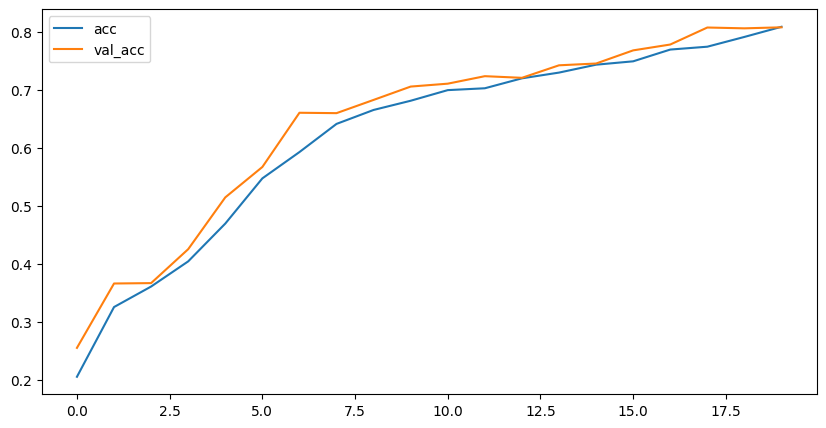

In [ ]:
# 모델 설계
# 1. 뼈대 생성
model1 = Sequential()

# 2. 입력층
model1.add(InputLayer(shape=(28,28,1)))

model1.add(Flatten())

# 3. 중간층
model1.add(Dense(units=32, activation="sigmoid"))
model1.add(Dense(units=16, activation="sigmoid"))
model1.add(Dense(units=8, activation="sigmoid"))

# 4. 출력층
model1.add(Dense(units=10, activation="softmax"))

# 모델 학습 방법
model1.compile(
    loss="sparse_categorical_crossentropy",
    optimizer = SGD(learning_rate=0.001, momentum=0.9),
    metrics=["accuracy"]
)

# 학습
h1 = model1.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 20
)

# accuracy, val_accuracy
plt.figure(figsize=(10, 5))
plt.plot(h1.history["accuracy"], label="acc")
plt.plot(h1.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3068 - loss: 2.1623 - val_accuracy: 0.4162 - val_loss: 1.5464
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5108 - loss: 1.3119 - val_accuracy: 0.6308 - val_loss: 1.0154
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7907 - loss: 0.7620 - val_accuracy: 0.8443 - val_loss: 0.6392
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8662 - loss: 0.5429 - val_accuracy: 0.8917 - val_loss: 0.4639
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8940 - loss: 0.4238 - val_accuracy: 0.9032 - val_loss: 0.3711
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9076 - loss: 0.3653 - val_accuracy: 0.9170 - val_loss: 0.3217
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9166 - loss: 0.3245 - val_accuracy: 0.9176 - val_loss: 0.3174
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9244 - loss: 0.2925 - 

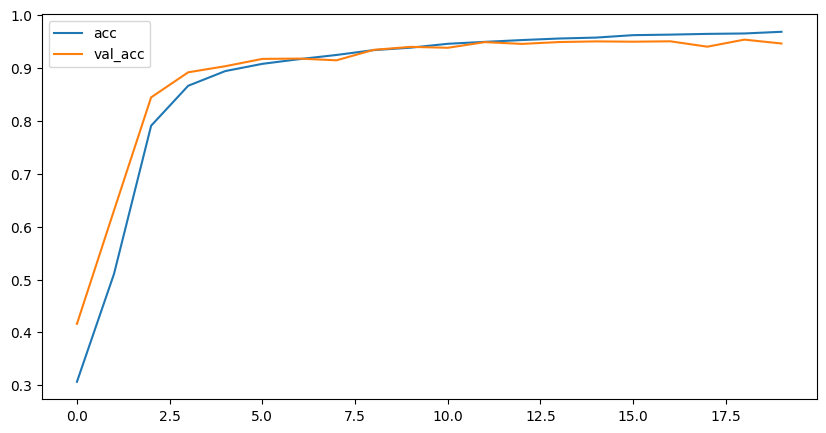

In [ ]:
# 모델 설계
# 1. 뼈대 생성
model2 = Sequential()

# 2. 입력층
model2.add(InputLayer(shape=(28,28,1)))

model2.add(Flatten())

# 3. 중간층
model2.add(Dense(units=32, activation="relu"))
model2.add(Dense(units=16, activation="relu"))
model2.add(Dense(units=8, activation="relu"))

# 4. 출력층
model2.add(Dense(units=10, activation="softmax"))

# 모델 학습 방법
model2.compile(
    loss="sparse_categorical_crossentropy",
    optimizer = Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

# 학습
h2 = model2.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 20
)

# accuracy, val_accuracy
plt.figure(figsize=(10, 5))
plt.plot(h2.history["accuracy"], label="acc")
plt.plot(h2.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4530 - loss: 1.7991 - val_accuracy: 0.6297 - val_loss: 1.0712
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6543 - loss: 1.0075 - val_accuracy: 0.6999 - val_loss: 0.8404
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6980 - loss: 0.8550 - val_accuracy: 0.7078 - val_loss: 0.7725
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7951 - loss: 0.6778 - val_accuracy: 0.8712 - val_loss: 0.5391
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8864 - loss: 0.4649 - val_accuracy: 0.9060 - val_loss: 0.3819
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9194 - loss: 0.3449 - val_accuracy: 0.9258 - val_loss: 0.3345
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9324 - loss: 0.2788 - val_accuracy: 0.9357 - val_loss: 0.3107
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9403 - loss: 0.2506 - 

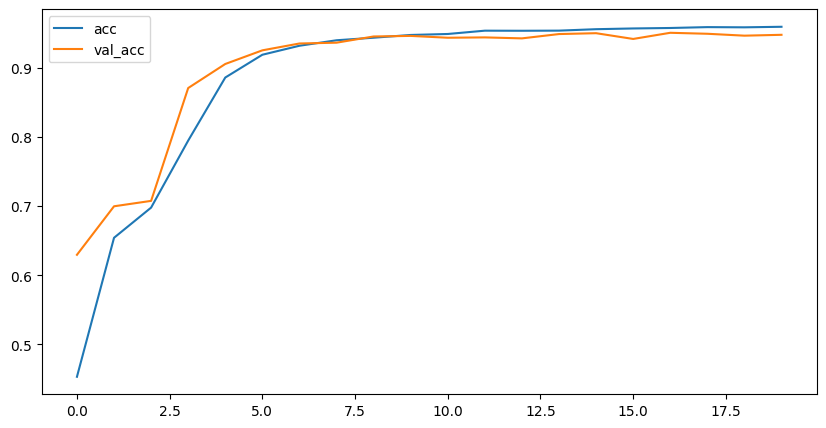

In [ ]:
# 모델 설계
# 1. 뼈대 생성
model3 = Sequential()

# 2. 입력층
model3.add(InputLayer(shape=(28,28,1)))

model3.add(Flatten())

# 3. 중간층
model3.add(Dense(units=32, activation="relu"))
model3.add(Dense(units=16, activation="relu"))
model3.add(Dense(units=8, activation="relu"))

# 4. 출력층
model3.add(Dense(units=10, activation="softmax"))

# 모델 학습 방법
model3.compile(
    loss="sparse_categorical_crossentropy",
    optimizer = "RMSprop",
    metrics=["accuracy"]
)

# 학습
h3 = model3.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 20
)

# accuracy, val_accuracy
plt.figure(figsize=(10, 5))
plt.plot(h3.history["accuracy"], label="acc")
plt.plot(h3.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

In [ ]:
# 최종 캡쳐본
# 성능이 가장 안 좋은 모델 학습 현황 그래프

# 성능이 가장 좋은 모델 학습 현황 그래프

# 한 장으로 그래프 캡쳐해서 단톡방에 올리기

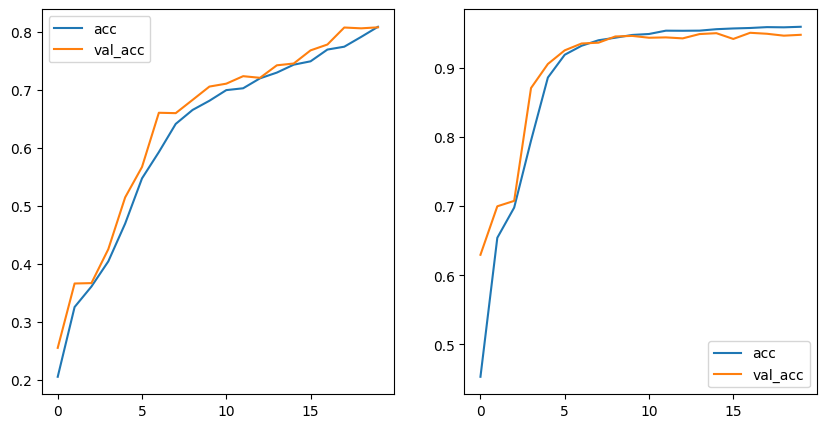

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(h1.history["accuracy"], label="acc")
plt.plot(h1.history["val_accuracy"], label="val_acc")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h3.history["accuracy"], label="acc")
plt.plot(h3.history["val_accuracy"], label="val_acc")
plt.legend()
plt.show()

### 내가 쓴 손글씨 맞춰보기

In [ ]:
%cd /content/drive/MyDrive/00 딥러닝

/content/drive/MyDrive/00 딥러닝


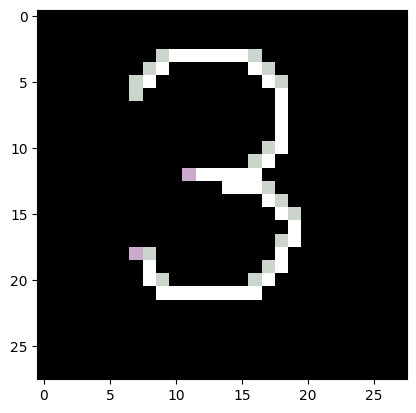

In [ ]:
import PIL.Image as pimg # 사진 파일 다루는 라이브러리
img = pimg.open("./data/손글씨3.gif")
plt.imshow(img)
plt.show()

In [ ]:
# 1차원으로 펴주는 Flatten이 받을 수 있도록 형변환 수행
# (28, 28) -> (n, 28, 28)
img.size

(28, 28)

In [ ]:
num = np.array(img) # 이미지 안에 있는 픽셀 값을 가지고 배열 생성
# 차원 수정 -> 문제 데이터와 동일한 형태로
num = num.reshape(1, 28, 28)

In [ ]:
model.predict(num)[0].argmax() # 두 겹으로 싸여 있으니까 안쪽으로 한 번 들어가준다
# 0~9까지 클래스에 속할 확률
# argmax() : 배열 중에 값이 가장 큰 index를 돌려줌 -> 예측한 답 클래스

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


np.int64(3)

In [ ]:
import PIL.ImageOps as ImageOps
img_gray = ImageOps